# REQUIREMENTS

In [2]:
!pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 69.1 MB/s eta 0:00:00


In [3]:
def show_random_image(seed):
    import os
    import glob
    import random
    import re
    import tifffile as tiff
    import matplotlib.pyplot as plt
    import numpy as np

    base_dir = "data"
    rng = random.Random(seed)

    image_paths = []

    for tif_path in sorted(glob.glob(os.path.join(base_dir, "**", "*.tif"), recursive=True)):
        norm_path = os.path.normpath(tif_path)
        parts = norm_path.split(os.sep)

        filename = parts[-1]
        parent_dir = parts[-2] if len(parts) >= 2 else ""

        if not re.fullmatch(r"t\d+\.tif", filename):
            continue
        if not re.fullmatch(r"\d{2}", parent_dir):
            continue

        # Exclude annotation folders anywhere in the path
        bad_part = False
        for p in parts:
            if p.endswith("_GT") or p.endswith("_ST") or p.endswith("_ERR_SEG") or p in {"GT", "SEG", "TRA"}:
                bad_part = True
                break
        if bad_part:
            continue

        dataset_container = parts[1] if len(parts) > 1 else "unknown"

        # dataset_name = folder before sequence unless that would be "data"
        dataset_name = parts[-3] if len(parts) >= 3 else dataset_container
        if dataset_name == dataset_container and len(parts) >= 4:
            dataset_name = parts[-3]

        image_paths.append((dataset_container, dataset_name, tif_path))

    unique_datasets = sorted(set((c, d) for c, d, _ in image_paths))
    print(f"Found {len(image_paths)} raw image frames across {len(unique_datasets)} datasets.")

    if not image_paths:
        raise ValueError("No raw .tif image frames found. Check your extracted folder structure.")

    dataset_container, dataset_name, chosen_path = rng.choice(image_paths)
    img = tiff.imread(chosen_path)

    parts = os.path.normpath(chosen_path).split(os.sep)
    sequence = parts[-2]
    filename = parts[-1]

    print(f"Seed: {seed}")
    print(f"Dataset container: {dataset_container}")
    print(f"Dataset name: {dataset_name}")
    print(f"Sequence: {sequence}")
    print(f"Frame: {filename}")
    print(f"Shape: {img.shape}")
    print(f"Dtype: {img.dtype}")
    print(f"Min: {img.min()}")
    print(f"Max: {img.max()}")
    print(f"Mean: {img.mean():.2f}")
    print(f"Std: {img.std():.2f}")

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.title(f"{dataset_name} | {sequence}/{filename}")
    plt.axis("off")
    plt.show()

In [4]:
# Create a directory to store datasets
import os
os.makedirs("data", exist_ok=True)

In [5]:
datasets = {

    # --- Fluorescence (2D + time) ---
    "Fluo-C2DL-Huh7_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-C2DL-Huh7.zip",
    "Fluo-C2DL-Huh7_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-C2DL-Huh7.zip",

    "Fluo-C2DL-MSC_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-C2DL-MSC.zip",
    "Fluo-C2DL-MSC_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-C2DL-MSC.zip",

    "Fluo-N2DH-GOWT1_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DH-GOWT1.zip",
    "Fluo-N2DH-GOWT1_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-N2DH-GOWT1.zip",

    "Fluo-N2DL-HeLa_train": "https://data.celltrackingchallenge.net/training-datasets/Fluo-N2DL-HeLa.zip",
    "Fluo-N2DL-HeLa_test":  "https://data.celltrackingchallenge.net/test-datasets/Fluo-N2DL-HeLa.zip",
}

In [6]:
for name, url in datasets.items():
    print(f"Downloading {name}...")

    zip_path = f"data/{name}.zip"
    extract_path = f"data/{name}"

    !wget -q -O {zip_path} {url}
    !unzip -oq {zip_path} -d {extract_path}

    # Delete only if exists
    if os.path.exists(zip_path):
        os.remove(zip_path)

# Cell Instance Tracking — Fluo-C2DL-Huh7
**Fully self-contained — no cellSAM dependency.**

- Images: `data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01/*.tif`
- Segmentation masks: `data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01_GT/SEG/*.tif`

Pipeline:
1. Load images + SEG masks
2. Preview
3. Tile stitching (`link_labels` — reimplemented here)
4. Temporal tracking (greedy IoU across frames)
5. Visualise results + trajectories
6. Save tracked masks

In [8]:
!pip install tifffile scipy scikit-learn numpy matplotlib --quiet

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import defaultdict
from pathlib import Path
from scipy import ndimage
import tifffile
import re

In [10]:
IMG_DIR = Path("data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01")
SEG_DIR = Path("data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01_GT/SEG")

def frame_index(p):
    m = re.search(r"(\d+)", p.stem)
    return int(m.group(1)) if m else -1

img_paths = sorted(IMG_DIR.glob("*.tif"), key=frame_index)
seg_paths = sorted(SEG_DIR.glob("*.tif"), key=frame_index)

print(f"Images : {len(img_paths)}")
print(f"Masks  : {len(seg_paths)}")
print()
for ip, sp in zip(img_paths[:5], seg_paths[:5]):
    print(f"  {ip.name}  <->  {sp.name}")

Images : 30
Masks  : 8

  t000.tif  <->  man_seg000.tif
  t001.tif  <->  man_seg002.tif
  t002.tif  <->  man_seg006.tif
  t003.tif  <->  man_seg014.tif
  t004.tif  <->  man_seg015.tif


In [11]:
images    = [tifffile.imread(p) for p in img_paths]
seg_masks = [tifffile.imread(p).astype(np.int32) for p in seg_paths]

H, W = images[0].shape[:2]
print(f"Frame size       : {H} x {W}")
print(f"Image dtype      : {images[0].dtype}")
print(f"Mask dtype       : {seg_masks[0].dtype}")
print(f"Instances frame 0: {seg_masks[0].max()}")

Frame size       : 1024 x 1024
Image dtype      : uint8
Mask dtype       : int32
Instances frame 0: 31


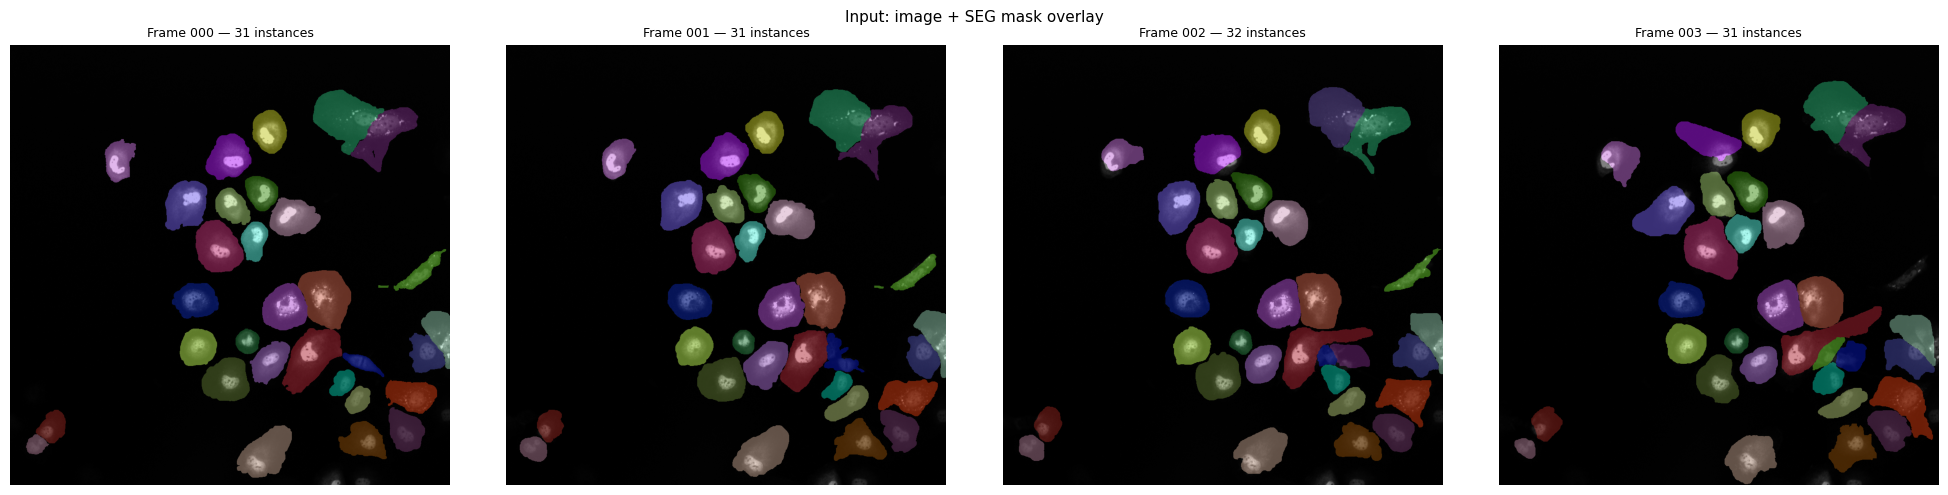

In [12]:
def make_cmap(n, seed=42):
    rng = np.random.default_rng(seed)
    colors = np.vstack([[0, 0, 0], rng.random((max(n, 1), 3))])
    return ListedColormap(colors)

def norm(img):
    img = img.astype(float)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

N_PREVIEW = min(4, len(images))
fig, axes = plt.subplots(1, N_PREVIEW, figsize=(5 * N_PREVIEW, 5))
if N_PREVIEW == 1:
    axes = [axes]
for i in range(N_PREVIEW):
    axes[i].imshow(norm(images[i]), cmap="gray")
    n = int(seg_masks[i].max())
    axes[i].imshow(seg_masks[i], cmap=make_cmap(n), alpha=0.5, vmin=0, vmax=max(n, 1))
    axes[i].set_title(f"Frame {i:03d} — {n} instances", fontsize=9)
    axes[i].axis("off")
plt.suptitle("Input: image + SEG mask overlay", fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# ── Reimplementation of cellSAM's link_labels logic ──────────────────────────

def compute_tile_iou(tile_a, tile_b):
    """IoU between all instance pairs in two overlapping tile regions."""
    ids_a = np.unique(tile_a[tile_a > 0])
    ids_b = np.unique(tile_b[tile_b > 0])
    pairs = []  # (id_a, id_b, iou)
    for ia in ids_a:
        ra = tile_a == ia
        for ib in ids_b:
            rb = tile_b == ib
            inter = np.logical_and(ra, rb).sum()
            if inter == 0:
                continue
            union = np.logical_or(ra, rb).sum()
            pairs.append((ia, ib, inter / union))
    return pairs


def union_find_merge(pairs, iou_threshold):
    """Union-Find to merge label pairs above iou_threshold.
    Returns a dict mapping old_id -> canonical_id."""
    parent = {}

    def find(x):
        while parent.get(x, x) != x:
            parent[x] = parent.get(parent.get(x, x), parent.get(x, x))
            x = parent.get(x, x)
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[ry] = rx  # keep lower id as root
            if ry < rx:
                parent[rx] = ry

    for ia, ib, iou in pairs:
        if iou >= iou_threshold:
            union(ia, ib)

    # Build final remapping
    all_ids = set(ia for ia, ib, _ in pairs) | set(ib for _, ib, _ in pairs)
    return {x: find(x) for x in all_ids}


def link_labels(tile_maps, positions, full_shape, overlap, iou_threshold=0.4):
    """
    Stitch per-tile label maps into a single consistent label map.

    Parameters
    ----------
    tile_maps     : list of (H_t, W_t) int arrays
    positions     : list of (row, col) top-left pixel coords per tile
    full_shape    : (H, W) of the full image
    overlap       : pixel overlap used when tiling
    iou_threshold : IoU above this → same instance

    Returns
    -------
    label_map : (H, W) int32
    """
    H, W = full_shape
    # Offset each tile's IDs so they don't collide globally
    offset_maps = []
    offset = 0
    offsets = []
    for tile in tile_maps:
        max_id = int(tile.max())
        offset_tile = np.where(tile > 0, tile + offset, 0).astype(np.int32)
        offset_maps.append(offset_tile)
        offsets.append(offset)
        offset += max_id + 1

    # Collect IoU pairs from overlapping borders between adjacent tiles
    all_pairs = []
    n = len(tile_maps)
    for i in range(n):
        ri, ci = positions[i]
        hi, wi = offset_maps[i].shape
        for j in range(i + 1, n):
            rj, cj = positions[j]
            hj, wj = offset_maps[j].shape
            # Compute overlap region in global coords
            r0 = max(ri, rj);  r1 = min(ri + hi, rj + hj)
            c0 = max(ci, cj);  c1 = min(ci + wi, cj + wj)
            if r1 - r0 <= 0 or c1 - c0 <= 0:
                continue
            # Extract overlap strips from each tile
            strip_i = offset_maps[i][r0 - ri: r1 - ri, c0 - ci: c1 - ci]
            strip_j = offset_maps[j][r0 - rj: r1 - rj, c0 - cj: c1 - cj]
            pairs = compute_tile_iou(strip_i, strip_j)
            all_pairs.extend(pairs)

    # Merge labels that refer to the same cell
    remap = union_find_merge(all_pairs, iou_threshold)

    # Paint tiles onto the full canvas, applying remap
    canvas = np.zeros((H, W), dtype=np.int32)
    for tile, (r, c) in zip(offset_maps, positions):
        ht, wt = tile.shape
        r1, c1 = min(r + ht, H), min(c + wt, W)
        region = tile[: r1 - r, : c1 - c].copy()
        # Apply remap vectorised
        remapped = np.vectorize(lambda x: remap.get(x, x))(region)
        # Non-zero pixels overwrite (last tile wins in overlap zone)
        mask = remapped > 0
        canvas[r:r1, c:c1][mask] = remapped[mask]

    # Re-index to compact sequential IDs
    _, canvas = np.unique(canvas, return_inverse=True)
    return canvas.reshape(H, W).astype(np.int32)


def tile_label_map(label_map, tile_size, overlap):
    """Split (H, W) label map into overlapping tiles with local re-indexing."""
    H, W   = label_map.shape
    stride = tile_size - overlap
    tiles, positions = [], []
    for r in range(0, H, stride):
        for c in range(0, W, stride):
            tile = label_map[r: r + tile_size, c: c + tile_size]
            _, reindexed = np.unique(tile, return_inverse=True)
            tiles.append(reindexed.reshape(tile.shape).astype(np.int32))
            positions.append((r, c))
    return tiles, positions


print("link_labels and helpers defined.")

link_labels and helpers defined.


In [14]:
TILE_SIZE     = 512
OVERLAP       = 64
IOU_THRESHOLD = 0.4

linked_masks = []
for i, seg in enumerate(seg_masks):
    tiles, positions = tile_label_map(seg, TILE_SIZE, OVERLAP)
    linked = link_labels(
        tiles, positions,
        full_shape=seg.shape,
        overlap=OVERLAP,
        iou_threshold=IOU_THRESHOLD,
    )
    linked_masks.append(linked)
    print(f"Frame {i:03d} | before: {seg.max():3d}  after: {linked.max():3d} instances")

print("\nTile stitching done.")

Frame 000 | before:  31  after:  31 instances
Frame 001 | before:  31  after:  31 instances
Frame 002 | before:  32  after:  32 instances
Frame 003 | before:  31  after:  31 instances
Frame 004 | before:  32  after:  32 instances
Frame 005 | before:  32  after:  32 instances
Frame 006 | before:  32  after:  32 instances
Frame 007 | before:  32  after:  32 instances

Tile stitching done.


In [15]:
def compute_iou_matrix(mask_a, mask_b):
    ids_a = np.unique(mask_a[mask_a > 0])
    ids_b = np.unique(mask_b[mask_b > 0])
    iou   = np.zeros((len(ids_a), len(ids_b)), dtype=np.float32)
    for i, ia in enumerate(ids_a):
        ra = mask_a == ia
        for j, ib in enumerate(ids_b):
            rb = mask_b == ib
            inter = np.logical_and(ra, rb).sum()
            if inter == 0:
                continue
            iou[i, j] = inter / np.logical_or(ra, rb).sum()
    return iou, ids_a, ids_b


def propagate_ids(linked_masks, iou_threshold=0.3):
    tracked        = [linked_masks[0].copy()]
    next_global_id = int(linked_masks[0].max()) + 1

    for t in range(1, len(linked_masks)):
        prev      = tracked[t - 1]
        curr      = linked_masks[t].copy()
        new_frame = np.zeros_like(curr)

        iou_mat, ids_prev, ids_curr = compute_iou_matrix(prev, curr)
        matched_curr = set()

        if iou_mat.size > 0:
            for i_idx in np.argsort(-iou_mat.max(axis=1)):
                j_idx = iou_mat[i_idx].argmax()
                if iou_mat[i_idx, j_idx] >= iou_threshold:
                    curr_id = ids_curr[j_idx]
                    if curr_id not in matched_curr:
                        new_frame[curr == curr_id] = ids_prev[i_idx]
                        matched_curr.add(curr_id)

        for curr_id in np.unique(curr[curr > 0]):
            if curr_id not in matched_curr:
                new_frame[curr == curr_id] = next_global_id
                next_global_id += 1

        tracked.append(new_frame)
        n_new = len(np.unique(curr[curr > 0])) - len(matched_curr)
        print(f"Frame {t:03d} | matched: {len(matched_curr):3d}  new: {n_new:3d}  total IDs so far: {next_global_id - 1}")

    return tracked


tracked_masks = propagate_ids(linked_masks, iou_threshold=0.3)
print(f"\nTracking complete — {len(tracked_masks)} frames.")

Frame 001 | matched:  30  new:   1  total IDs so far: 32
Frame 002 | matched:  30  new:   2  total IDs so far: 34
Frame 003 | matched:  31  new:   0  total IDs so far: 34
Frame 004 | matched:  31  new:   1  total IDs so far: 35
Frame 005 | matched:  32  new:   0  total IDs so far: 35
Frame 006 | matched:  31  new:   1  total IDs so far: 36
Frame 007 | matched:  32  new:   0  total IDs so far: 36

Tracking complete — 8 frames.


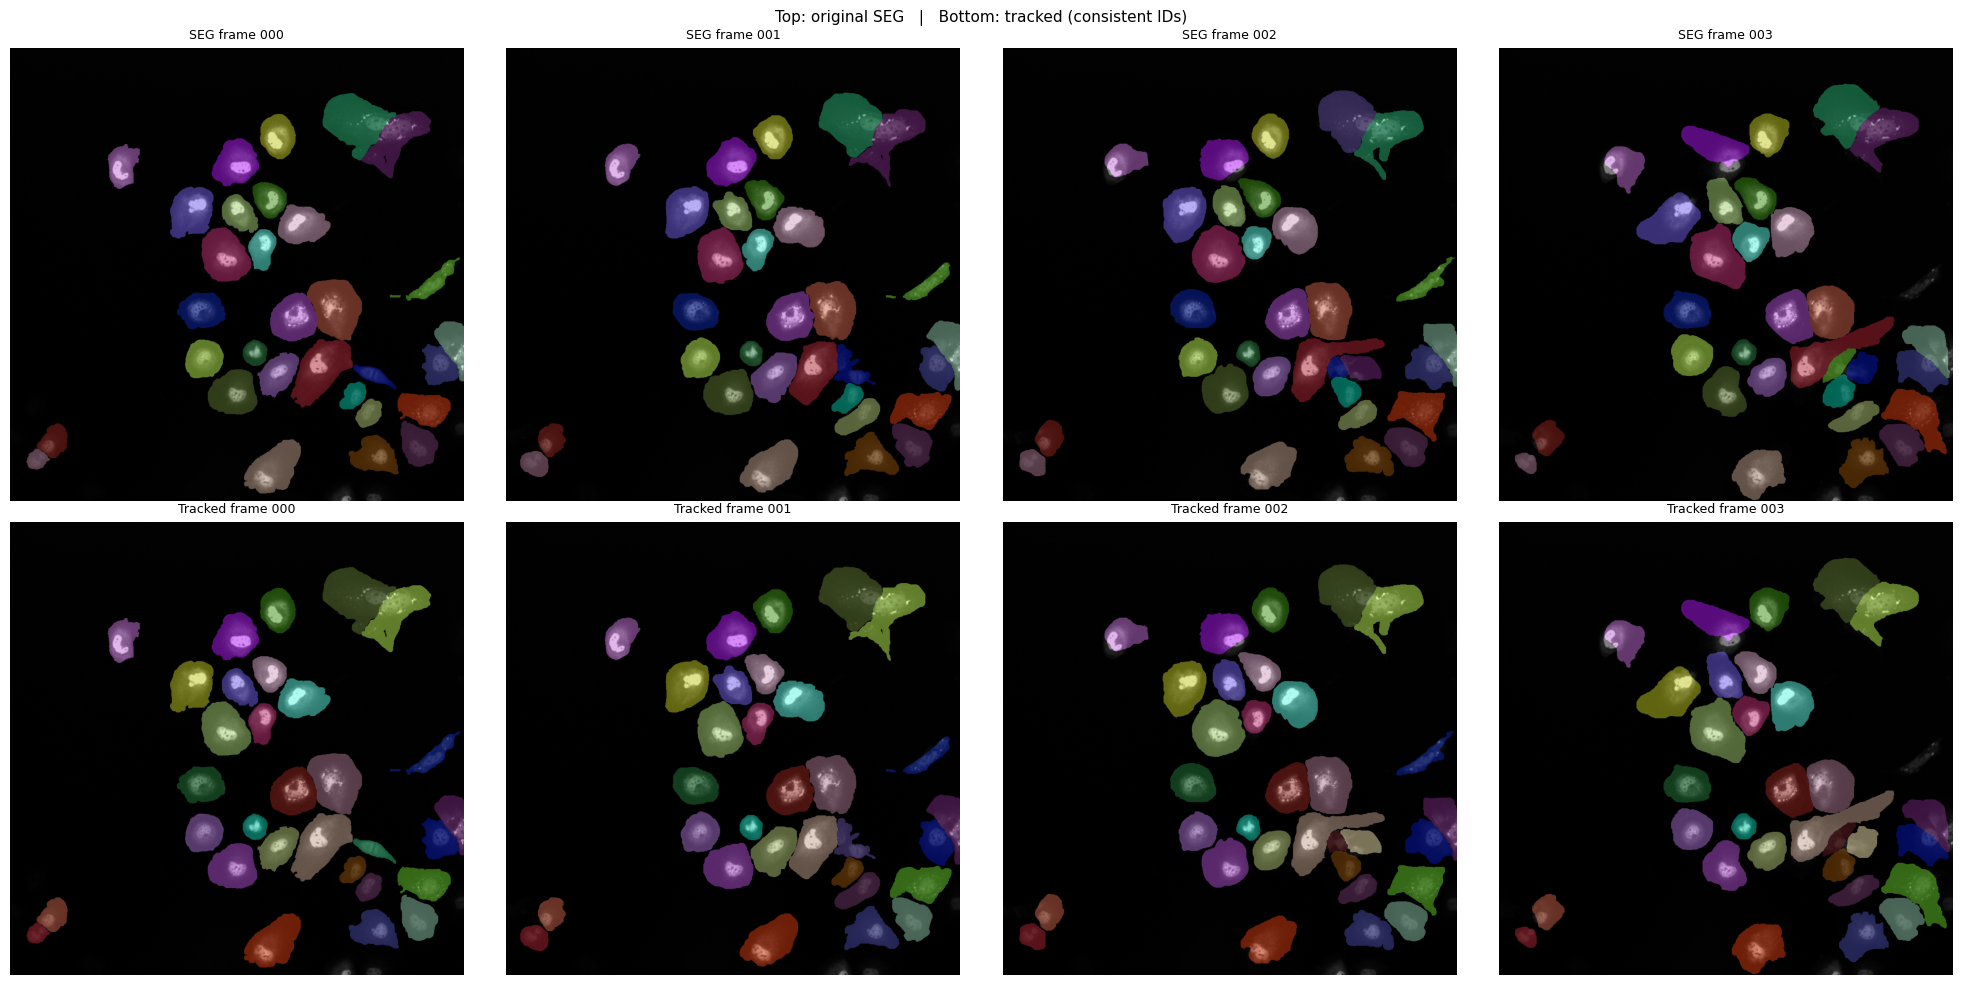

In [16]:
N_VIS      = min(4, len(images))
global_max = max(m.max() for m in tracked_masks)
cmap_t     = make_cmap(int(global_max))

fig, axes = plt.subplots(2, N_VIS, figsize=(5 * N_VIS, 10))
for i in range(N_VIS):
    img_n = norm(images[i])
    axes[0, i].imshow(img_n, cmap="gray")
    axes[0, i].imshow(seg_masks[i], cmap=make_cmap(int(seg_masks[i].max())),
                      alpha=0.5, vmin=0, vmax=max(int(seg_masks[i].max()), 1))
    axes[0, i].set_title(f"SEG frame {i:03d}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(img_n, cmap="gray")
    axes[1, i].imshow(tracked_masks[i], cmap=cmap_t,
                      alpha=0.5, vmin=0, vmax=global_max)
    axes[1, i].set_title(f"Tracked frame {i:03d}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Top: original SEG   |   Bottom: tracked (consistent IDs)", fontsize=11)
plt.tight_layout()
plt.show()

Cells tracked across ≥3 frames: 32


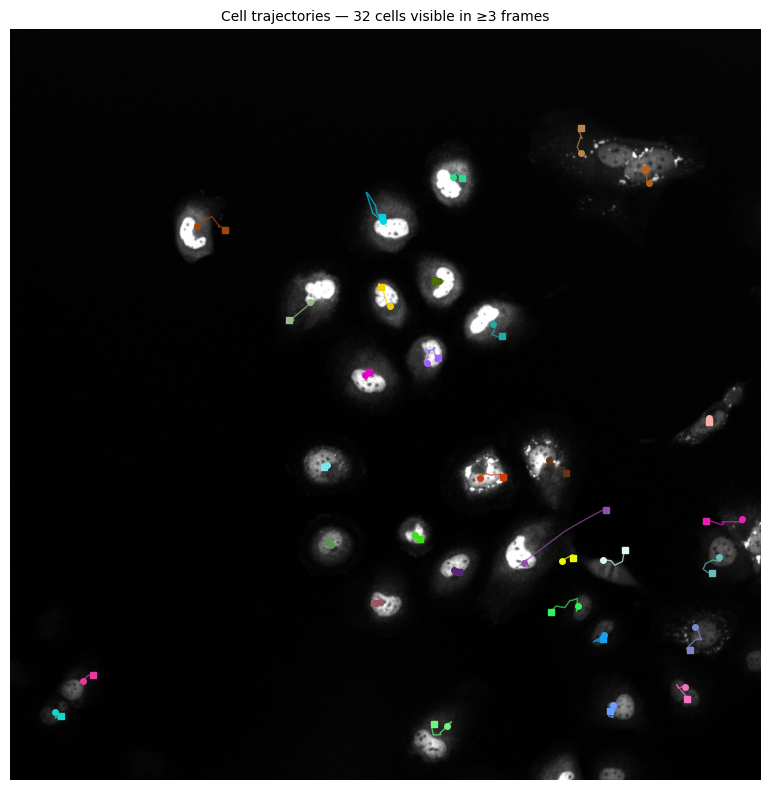

In [17]:
trajectories = defaultdict(list)
for t, mask in enumerate(tracked_masks):
    for cell_id in np.unique(mask[mask > 0]):
        cy, cx = ndimage.center_of_mass(mask == cell_id)
        trajectories[cell_id].append((t, cy, cx))

long_tracks = {k: v for k, v in trajectories.items() if len(v) >= 3}
print(f"Cells tracked across ≥3 frames: {len(long_tracks)}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(norm(images[0]), cmap="gray")

rng = np.random.default_rng(0)
for cell_id, pts in long_tracks.items():
    ts, ys, xs = zip(*pts)
    color = rng.random(3)
    ax.plot(xs, ys, "-", color=color, linewidth=1, alpha=0.7)
    ax.plot(xs[0],  ys[0],  "o", color=color, markersize=4)   # start
    ax.plot(xs[-1], ys[-1], "s", color=color, markersize=4)   # end

ax.set_title(f"Cell trajectories — {len(long_tracks)} cells visible in ≥3 frames", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

Total unique cells tracked : 36
Lifespan — mean            : 7.0 frames
Lifespan — median          : 8 frames
Cells present all frames   : 29


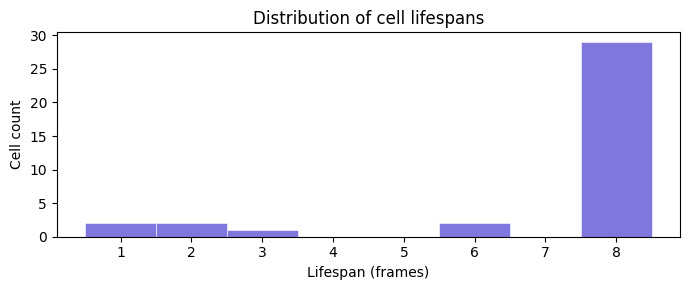

In [18]:
lifespans = {k: len(v) for k, v in trajectories.items()}
lifespan_vals = np.array(list(lifespans.values()))

print(f"Total unique cells tracked : {len(lifespans)}")
print(f"Lifespan — mean            : {lifespan_vals.mean():.1f} frames")
print(f"Lifespan — median          : {np.median(lifespan_vals):.0f} frames")
print(f"Cells present all frames   : {(lifespan_vals == len(tracked_masks)).sum()}")

plt.figure(figsize=(7, 3))
plt.hist(lifespan_vals, bins=range(1, len(tracked_masks) + 2), color="#7F77DD",
         edgecolor="white", linewidth=0.4, align="left")
plt.xlabel("Lifespan (frames)")
plt.ylabel("Cell count")
plt.title("Distribution of cell lifespans")
plt.tight_layout()
plt.show()

Loading 30 Ground Truth TRA masks...
GT cells tracked across ≥3 frames: 34


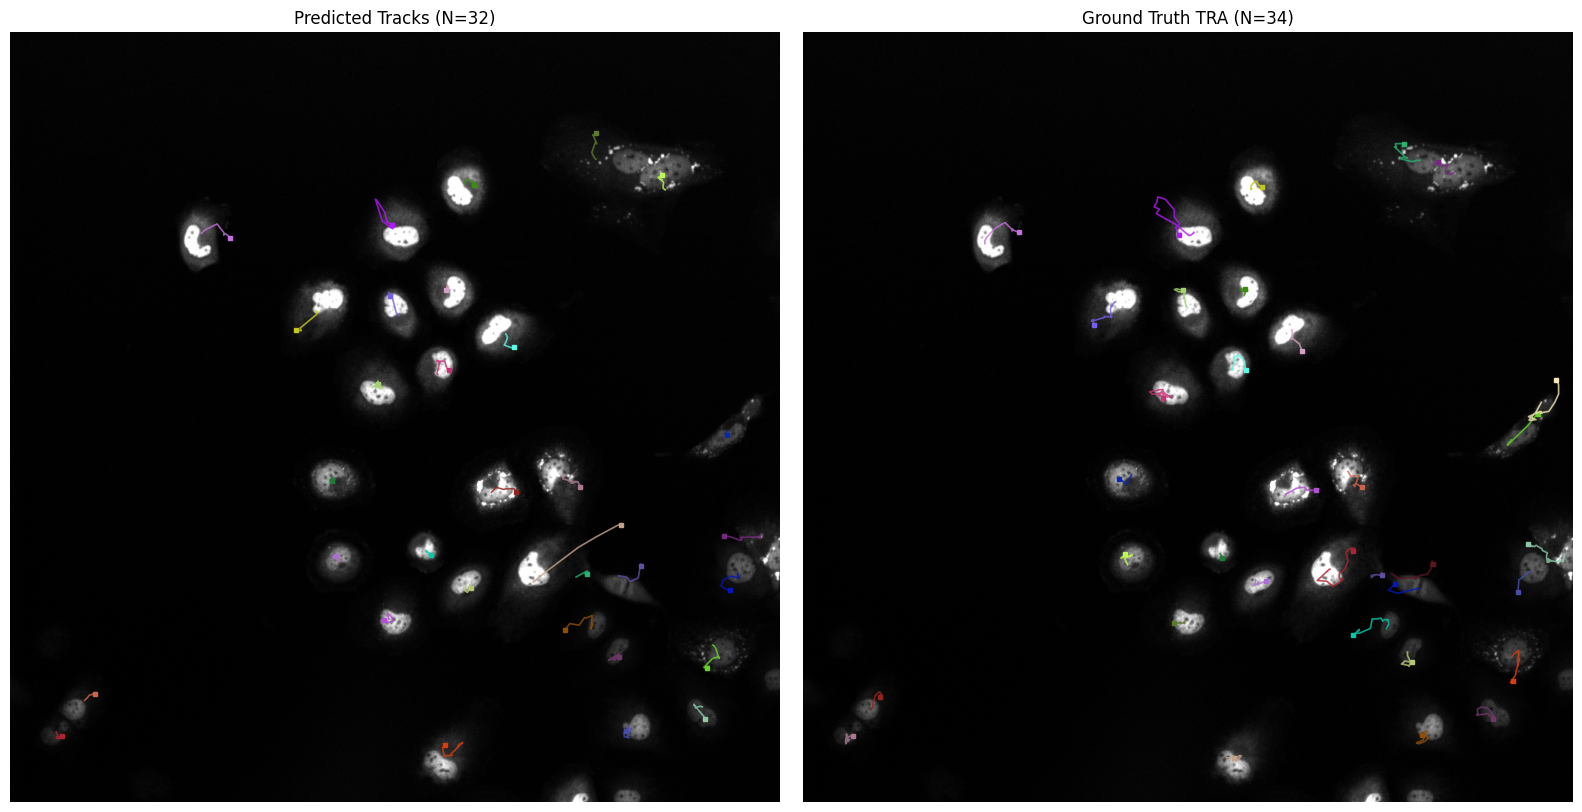

------------------------------
Tracking Performance Heuristics
------------------------------
Unique IDs Found     | Pred: 36    | GT: 34
Mean Track Duration  | Pred: 7.03  | GT: 27.97 frames
Max Track Duration   | Pred: 8     | GT: 30


In [19]:
# 1. Define paths and load TRA masks
TRA_DIR = Path("data/Fluo-C2DL-Huh7_train/Fluo-C2DL-Huh7/01_GT/TRA")
tra_paths = sorted(TRA_DIR.glob("*.tif"), key=frame_index)

print(f"Loading {len(tra_paths)} Ground Truth TRA masks...")
tra_masks = [tifffile.imread(p).astype(np.int32) for p in tra_paths]

# 2. Extract GT Trajectories
gt_trajectories = defaultdict(list)
for t, mask in enumerate(tra_masks):
    # In TRA masks, unique non-zero values are consistent instance IDs
    for cell_id in np.unique(mask[mask > 0]):
        # Center of mass handles both single-pixel markers and larger blobs
        cy, cx = ndimage.center_of_mass(mask == cell_id)
        gt_trajectories[cell_id].append((t, cy, cx))

# 3. Filter for long tracks (visible in >= 3 frames)
gt_long_tracks = {k: v for k, v in gt_trajectories.items() if len(v) >= 3}
print(f"GT cells tracked across ≥3 frames: {len(gt_long_tracks)}")

# 4. Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

def plot_paths(ax, title, tracks, bg_img):
    ax.imshow(norm(bg_img), cmap="gray")
    # Use a fixed seed so colors stay consistent during re-runs
    r_gen = np.random.default_rng(42)
    for cell_id, pts in tracks.items():
        ts, ys, xs = zip(*pts)
        color = r_gen.random(3)
        ax.plot(xs, ys, "-", color=color, linewidth=1.2, alpha=0.8)
        ax.plot(xs[-1], ys[-1], "s", color=color, markersize=3) # Square = End
    ax.set_title(title)
    ax.axis("off")

# Plot your results vs Ground Truth
plot_paths(axes[0], f"Predicted Tracks (N={len(long_tracks)})", long_tracks, images[0])
plot_paths(axes[1], f"Ground Truth TRA (N={len(gt_long_tracks)})", gt_long_tracks, images[0])

plt.tight_layout()
plt.show()

# 5. Simple Statistical Comparison
print("-" * 30)
print("Tracking Performance Heuristics")
print("-" * 30)
pred_lens = [len(v) for v in trajectories.values()]
gt_lens = [len(v) for v in gt_trajectories.values()]

print(f"Unique IDs Found     | Pred: {len(trajectories):<5} | GT: {len(gt_trajectories)}")
print(f"Mean Track Duration  | Pred: {np.mean(pred_lens):.2f}  | GT: {np.mean(gt_lens):.2f} frames")
print(f"Max Track Duration   | Pred: {np.max(pred_lens):<5} | GT: {np.max(gt_lens)}")

## Evaluation Metric

In [22]:
def calculate_seg_score(pred_masks, gt_seg_masks):
    """
    SEG Measure: Average Jaccard index (IoU) of matched objects.
    Note: Only GT objects with a matching prediction (IoU > 0.5) contribute
    their IoU; unmatched GT objects contribute 0.
    """
    ious = []
    for p_mask, g_mask in zip(pred_masks, gt_seg_masks):
        g_ids = np.unique(g_mask[g_mask > 0])
        p_ids = np.unique(p_mask[p_mask > 0])

        if len(g_ids) == 0:
            continue

        for gid in g_ids:
            target = (g_mask == gid)
            best_iou = 0
            # Find the overlapping predicted object
            overlapping_p_ids = np.unique(p_mask[target])
            for pid in overlapping_p_ids:
                if pid == 0: continue
                pred = (p_mask == pid)
                inter = np.logical_and(target, pred).sum()
                union = np.logical_or(target, pred).sum()
                iou = inter / union
                if iou > 0.5: # CTC requirement for a match
                    best_iou = iou
                    break
            ious.append(best_iou)

    return np.mean(ious) if ious else 0.0

def calculate_det_tra_lite(pred_masks, tra_masks):
    """
    DET/TRA Proxy:
    - DET: Fraction of GT markers covered by exactly one prediction.
    - TRA: Consistency of IDs across temporal links.
    """
    det_hits = 0
    total_markers = 0

    # Tracking links: (time, gt_id) -> pred_id
    links = {}

    for t, (p_mask, g_mask) in enumerate(zip(pred_masks, tra_masks)):
        g_ids = np.unique(g_mask[g_mask > 0])
        total_markers += len(g_ids)

        for gid in g_ids:
            # Get location of the GT marker
            marker_coords = np.where(g_mask == gid)
            # Find our predicted ID at that location
            hits = p_mask[marker_coords]
            hits = hits[hits > 0]

            if len(hits) > 0:
                pred_id = hits[0]
                det_hits += 1
                links[(t, gid)] = pred_id

    # Calculate DET (Detection Score)
    det_score = det_hits / total_markers if total_markers > 0 else 0

    # Calculate TRA (Tracking Consistency)
    # Check if the same GT cell (gid) keeps the same Pred ID across frames
    correct_links = 0
    total_links = 0

    gt_ids = set(k[1] for k in links.keys())
    for gid in gt_ids:
        # Find all frames where this GT cell exists
        frames = sorted([k[0] for k in links.keys() if k[1] == gid])
        for i in range(len(frames) - 1):
            t1, t2 = frames[i], frames[i+1]
            total_links += 1
            if links[(t1, gid)] == links[(t2, gid)]:
                correct_links += 1

    tra_score = correct_links / total_links if total_links > 0 else 0

    return det_score, tra_score

# --- Execution ---

# Load GT SEG masks if not already loaded (for SEG score)
# Assuming 'seg_masks' from Section 2 are the Ground Truth masks
seg_score = calculate_seg_score(tracked_masks, seg_masks)

# Load TRA masks for DET and TRA scores
det_score, tra_score = calculate_det_tra_lite(tracked_masks, tra_masks)

# Final Overall Performance (OP) as defined by the challenge
op_score = 0.5 * (seg_score + tra_score)

print(f"{'='*30}")
print(f" CTC EVALUATION RESULTS")
print(f"{'='*30}")
print(f" SEG (Segmentation) : {seg_score:.4f}")
print(f" DET (Detection)    : {det_score:.4f}")
print(f" TRA (Tracking)     : {tra_score:.4f}")
print(f"{'-'*30}")
print(f" OP (Overall Score) : {op_score:.4f}")
print(f"{'='*30}")

 CTC EVALUATION RESULTS
 SEG (Segmentation) : 1.0000
 DET (Detection)    : 0.9722
 TRA (Tracking)     : 0.9906
------------------------------
 OP (Overall Score) : 0.9953
